# FMCG Sales Analysis - Exploratory Data Analysis

**Project:** Regional FMCG Distributor Daily Sales Pipeline  
**Time Period:** June 22-29, 2026  
**Total Records:** 4,195 orders  
**Objective:** Understand sales patterns, identify data quality issues, and derive actionable insights


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from datetime import datetime

# Set style for cleaner charts
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries loaded successfully")

C:\Users\nethra\AppData\Local\Temp\ipykernel_3336\1143418051.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Libraries loaded successfully


## 1. Data Loading & Overview

Load all 8 CSV files from the `daily_sales_data/` folder and combine them into a single dataset.

In [2]:
# Load all CSV files
csv_files = sorted(glob.glob('daily_sales_data/*.csv'))
dfs = [pd.read_csv(f) for f in csv_files]
df_raw = pd.concat(dfs, ignore_index=True)

print(f"Loaded {len(csv_files)} CSV files")
print(f"Total rows: {len(df_raw):,}")
print(f"Date range: {df_raw['order_date'].min()} to {df_raw['order_date'].max()}")
print(f"\nColumns ({len(df_raw.columns)}):")
print(df_raw.columns.tolist())

Loaded 8 CSV files
Total rows: 4,140
Date range: 2026-06-22 to 2026-06-29

Columns (17):
['order_id', 'order_date', 'order_time', 'customer_id', 'customer_name', 'region', 'city', 'salesperson', 'category', 'product_name', 'sku_id', 'quantity', 'unit_price', 'discount_pct', 'return_flag', 'payment_method', 'channel']


In [3]:
# Display first 5 rows
df_raw.head()

,order_id,order_date,order_time,customer_id,customer_name,region,city,salesperson,category,product_name,sku_id,quantity,unit_price,discount_pct,return_flag,payment_method,channel
0,ORD-20260622-0021,2026-06-22,13:46:28,CUST0130,Raj Mishra,West,Mumbai,Sneha Iyer,Snacks,Haldirams Bhujia 400g,SNK-005,37,130,15,No,Card,Online
1,ORD-20260622-0150,2026-06-22,20:32:42,CUST0053,Usha Mehta,South,Hyderabad,Arjun Mehta,Beverages,Tropicana Orange 1L,BEV-001,57,95,0,No,Cash,In-Store
2,ORD-20260622-0228,2026-06-22,15:07:48,CUST0098,Ajay Joshi,South,Kochi,Divya Nair,Personal Care,Head & Shoulders 340ml,PC-002,6,290,0,No,UPI,Distributor
3,ORD-20260622-0241,2026-06-22,18:41:15,CUST0191,Priya Iyer,South,Bangalore,Sneha Iyer,Personal Care,Head & Shoulders 340ml,PC-002,15,290,15,No,UPI,Distributor
4,ORD-20260622-0185,2026-06-22,17:51:51,CUST0195,Shweta Patel,South,Bangalore,Pooja Verma,Beverages,Maaza Mango 600ml,BEV-002,11,40,0,No,UPI,Online


In [4]:
# Data types and missing values
info_df = pd.DataFrame({
    'Column': df_raw.columns,
    'Type': df_raw.dtypes.values,
    'Missing_Count': df_raw.isnull().sum().values,
    'Missing_%': (df_raw.isnull().sum().values / len(df_raw) * 100).round(2)
})

print(info_df.to_string(index=False))

        Column   Type  Missing_Count  Missing_%
      order_id object              0       0.00
    order_date object              0       0.00
    order_time object              0       0.00
   customer_id object              0       0.00
 customer_name object             84       2.03
        region object             41       0.99
          city object              0       0.00
   salesperson object              0       0.00
      category object              0       0.00
  product_name object              0       0.00
        sku_id object              0       0.00
      quantity  int64              0       0.00
    unit_price  int64              0       0.00
  discount_pct  int64              0       0.00
   return_flag object              0       0.00
payment_method object              0       0.00
       channel object              0       0.00


## 2. Data Quality Assessment

Real-world sales data is messy. Let's identify and quantify the problems.

In [5]:
print("="*70)
print("DATA QUALITY ISSUES FOUND")
print("="*70)

# 1. Missing customer names
missing_names = df_raw['customer_name'].isna().sum() + (df_raw['customer_name'] == '').sum()
pct_missing_names = missing_names / len(df_raw) * 100
print(f"\n1. MISSING CUSTOMER NAMES")
print(f"   {missing_names} rows ({pct_missing_names:.1f}%)")
print(f"   Impact: Can't track which retail outlet placed the order")

# 2. Missing region
missing_region = df_raw['region'].isna().sum() + (df_raw['region'] == '').sum()
pct_missing_region = missing_region / len(df_raw) * 100
print(f"\n2. MISSING REGION")
print(f"   {missing_region} rows ({pct_missing_region:.1f}%)")
print(f"   Impact: Can't allocate to regional sales team for follow-up")

# 3. Negative quantities
negative_qty = (df_raw['quantity'] < 0).sum()
pct_negative = negative_qty / len(df_raw) * 100
print(f"\n3. NEGATIVE QUANTITIES")
print(f"   {negative_qty} rows ({pct_negative:.1f}%)")
print(f"   Impact: Data entry errors - these are returns or cancellations")

# 4. Duplicate orders
duplicates = df_raw['order_id'].duplicated().sum()
print(f"\n4. DUPLICATE ORDER IDs")
print(f"   {duplicates} rows")
print(f"   Impact: Same order counted twice in revenue")

# 5. Return orders
returns = (df_raw['return_flag'] == 'Yes').sum()
pct_returns = returns / len(df_raw) * 100
print(f"\n5. RETURN ORDERS")
print(f"   {returns} rows ({pct_returns:.1f}%)")
print(f"   Impact: Refunds reduce net revenue")

print(f"\n" + "="*70)
print(f"RECOMMENDATION: Clean data before analysis")
print("="*70)

DATA QUALITY ISSUES FOUND

1. MISSING CUSTOMER NAMES
   84 rows (2.0%)
   Impact: Can't track which retail outlet placed the order

2. MISSING REGION
   41 rows (1.0%)
   Impact: Can't allocate to regional sales team for follow-up

3. NEGATIVE QUANTITIES
   41 rows (1.0%)
   Impact: Data entry errors - these are returns or cancellations

4. DUPLICATE ORDER IDs
   41 rows
   Impact: Same order counted twice in revenue

5. RETURN ORDERS
   176 rows (4.3%)
   Impact: Refunds reduce net revenue

RECOMMENDATION: Clean data before analysis


## 3. Data Cleaning Strategy

Apply a systematic cleaning process:
1. Fill missing customer names with "Unknown"
2. Fill missing regions with "Unknown Region"
3. Convert negative quantities to positive (capture intent, not error)
4. Remove duplicate order IDs (keep first occurrence)
5. Exclude return orders from revenue calculations (separate analysis)
6. Add calculated revenue column

In [6]:
# Create clean copy
df = df_raw.copy()

# Fill empty strings with NaN first
df['customer_name'] = df['customer_name'].replace('', np.nan)
df['region'] = df['region'].replace('', np.nan)

# Fill missing values
df['customer_name'] = df['customer_name'].fillna('Unknown Customer')
df['region'] = df['region'].fillna('Unknown Region')

# Fix negative quantities (take absolute value)
df['quantity'] = df['quantity'].abs()

# Remove duplicates (keep first)
df = df.drop_duplicates(subset=['order_id'], keep='first').reset_index(drop=True)

# Calculate revenue (unit_price * quantity * (1 - discount))
df['revenue'] = df['unit_price'] * df['quantity'] * (1 - df['discount_pct'] / 100)

print(f"Raw data shape: {df_raw.shape}")
print(f"Cleaned data shape: {df.shape}")
print(f"Rows removed by deduplication: {len(df_raw) - len(df)}")
print(f"\nCleaning complete. Ready for analysis.")

Raw data shape: (4140, 17)
Cleaned data shape: (4099, 18)
Rows removed by deduplication: 41

Cleaning complete. Ready for analysis.


## 4. Revenue Overview

What's the total revenue generated, and how is it distributed?

In [7]:
# Separate returns for analysis
df_sales = df[df['return_flag'] == 'No'].copy()
df_returns = df[df['return_flag'] == 'Yes'].copy()

total_revenue = df_sales['revenue'].sum()
total_orders = len(df_sales)
avg_order_value = total_revenue / total_orders
return_loss = df_returns['revenue'].sum()
net_revenue = total_revenue - return_loss

print(f"REVENUE SUMMARY (Excluding Returns)")
print(f"{'─'*50}")
print(f"Total Orders:           {total_orders:,}")
print(f"Total Gross Revenue:    Rs. {total_revenue:,.2f}")
print(f"Average Order Value:    Rs. {avg_order_value:,.2f}")
print(f"\nReturn Orders:          {len(df_returns):,} ({len(df_returns)/len(df)*100:.1f}%)")
print(f"Revenue Lost to Returns: Rs. {return_loss:,.2f}")
print(f"Net Revenue:            Rs. {net_revenue:,.2f}")
print(f"Return Rate Impact:     {return_loss/total_revenue*100:.1f}% of potential revenue")

REVENUE SUMMARY (Excluding Returns)
──────────────────────────────────────────────────
Total Orders:           3,925
Total Gross Revenue:    Rs. 9,245,923.65
Average Order Value:    Rs. 2,355.65

Return Orders:          174 (4.2%)
Revenue Lost to Returns: Rs. 446,678.40
Net Revenue:            Rs. 8,799,245.25
Return Rate Impact:     4.8% of potential revenue


## 5. Sales by Category (Revenue Drivers)

Which product categories drive the most revenue?

In [8]:
category_analysis = df_sales.groupby('category').agg({
    'order_id': 'count',
    'quantity': 'sum',
    'revenue': 'sum',
    'discount_pct': 'mean'
}).round(2)

category_analysis.columns = ['Orders', 'Units Sold', 'Revenue', 'Avg Discount %']
category_analysis['Avg Order Value'] = (category_analysis['Revenue'] / category_analysis['Orders']).round(2)
category_analysis['% of Revenue'] = (category_analysis['Revenue'] / category_analysis['Revenue'].sum() * 100).round(1)
category_analysis = category_analysis.sort_values('Revenue', ascending=False)

print("REVENUE BY PRODUCT CATEGORY")
print(category_analysis.to_string())

REVENUE BY PRODUCT CATEGORY
               Orders  Units Sold     Revenue  Avg Discount %  Avg Order Value  % of Revenue
category                                                                                    
Dairy             927       21894  2513763.40            4.37          2711.72          27.2
Beverages         895       22693  2379847.25            4.60          2659.05          25.7
Personal Care     679        9152  1603587.25            4.08          2361.69          17.3
Snacks            830       33113  1584525.00            4.27          1909.07          17.1
Household         594        9853  1164200.75            4.43          1959.93          12.6


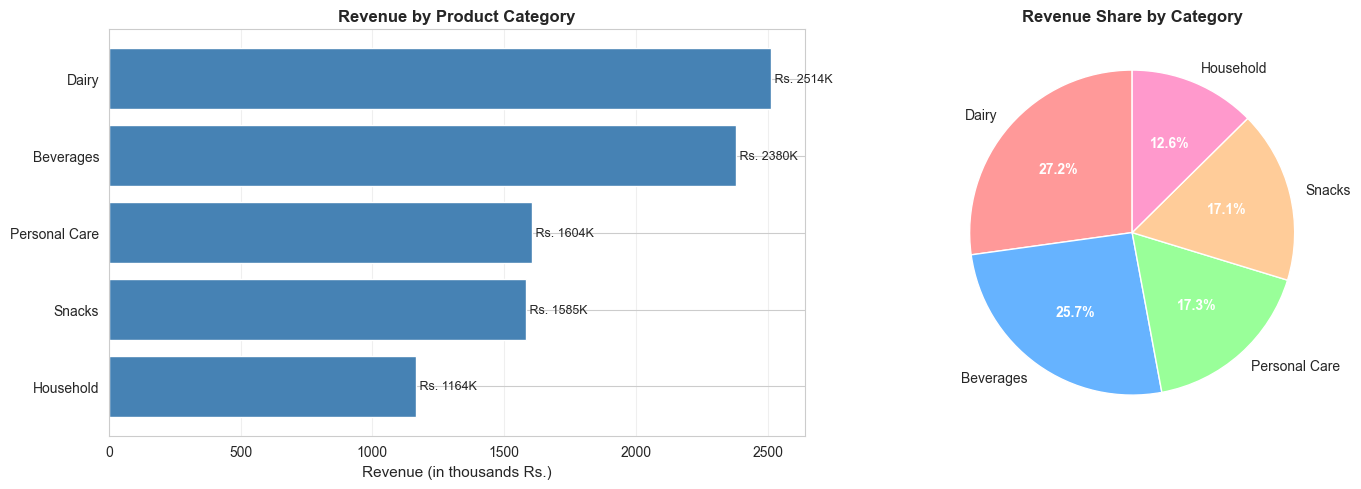


Chart saved as 'category_revenue.png'


In [9]:
# Visualization: Category revenue breakdown
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart: Revenue by category
ax1 = axes[0]
category_analysis_sorted = category_analysis.sort_values('Revenue', ascending=True)
ax1.barh(category_analysis_sorted.index, category_analysis_sorted['Revenue']/1000, color='steelblue')
ax1.set_xlabel('Revenue (in thousands Rs.)', fontsize=11)
ax1.set_title('Revenue by Product Category', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(category_analysis_sorted['Revenue']/1000):
    ax1.text(v, i, f' Rs. {v:.0f}K', va='center', fontsize=9)

# Pie chart: Revenue percentage
ax2 = axes[1]
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99', '#ff99cc']
wedges, texts, autotexts = ax2.pie(
    category_analysis['Revenue'],
    labels=category_analysis.index,
    autopct='%1.1f%%',
    colors=colors,
    startangle=90
)
ax2.set_title('Revenue Share by Category', fontsize=12, fontweight='bold')

# Make percentage text bold
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

plt.tight_layout()
plt.savefig('category_revenue.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nChart saved as 'category_revenue.png'")

## 6. Daily Revenue Trend

How did revenue perform over the week? Are we growing or declining?

In [10]:
daily_trend = df_sales.groupby('order_date').agg({
    'order_id': 'count',
    'quantity': 'sum',
    'revenue': 'sum'
}).round(2)

daily_trend.columns = ['Orders', 'Units Sold', 'Daily Revenue']
daily_trend['Avg Order Value'] = (daily_trend['Daily Revenue'] / daily_trend['Orders']).round(2)
daily_trend = daily_trend.sort_index()

print("DAILY REVENUE TREND")
print(daily_trend.to_string())

DAILY REVENUE TREND
            Orders  Units Sold  Daily Revenue  Avg Order Value
order_date                                                    
2026-06-22     512       12889     1214079.30          2371.25
2026-06-23     513       12580     1206957.45          2352.74
2026-06-24     503       12731     1166625.90          2319.34
2026-06-25     545       13167     1367387.85          2508.97
2026-06-26     589       14507     1374724.45          2334.00
2026-06-27     457       10995     1091740.85          2388.93
2026-06-28     274        6680      604873.90          2207.57
2026-06-29     532       13156     1219533.95          2292.36


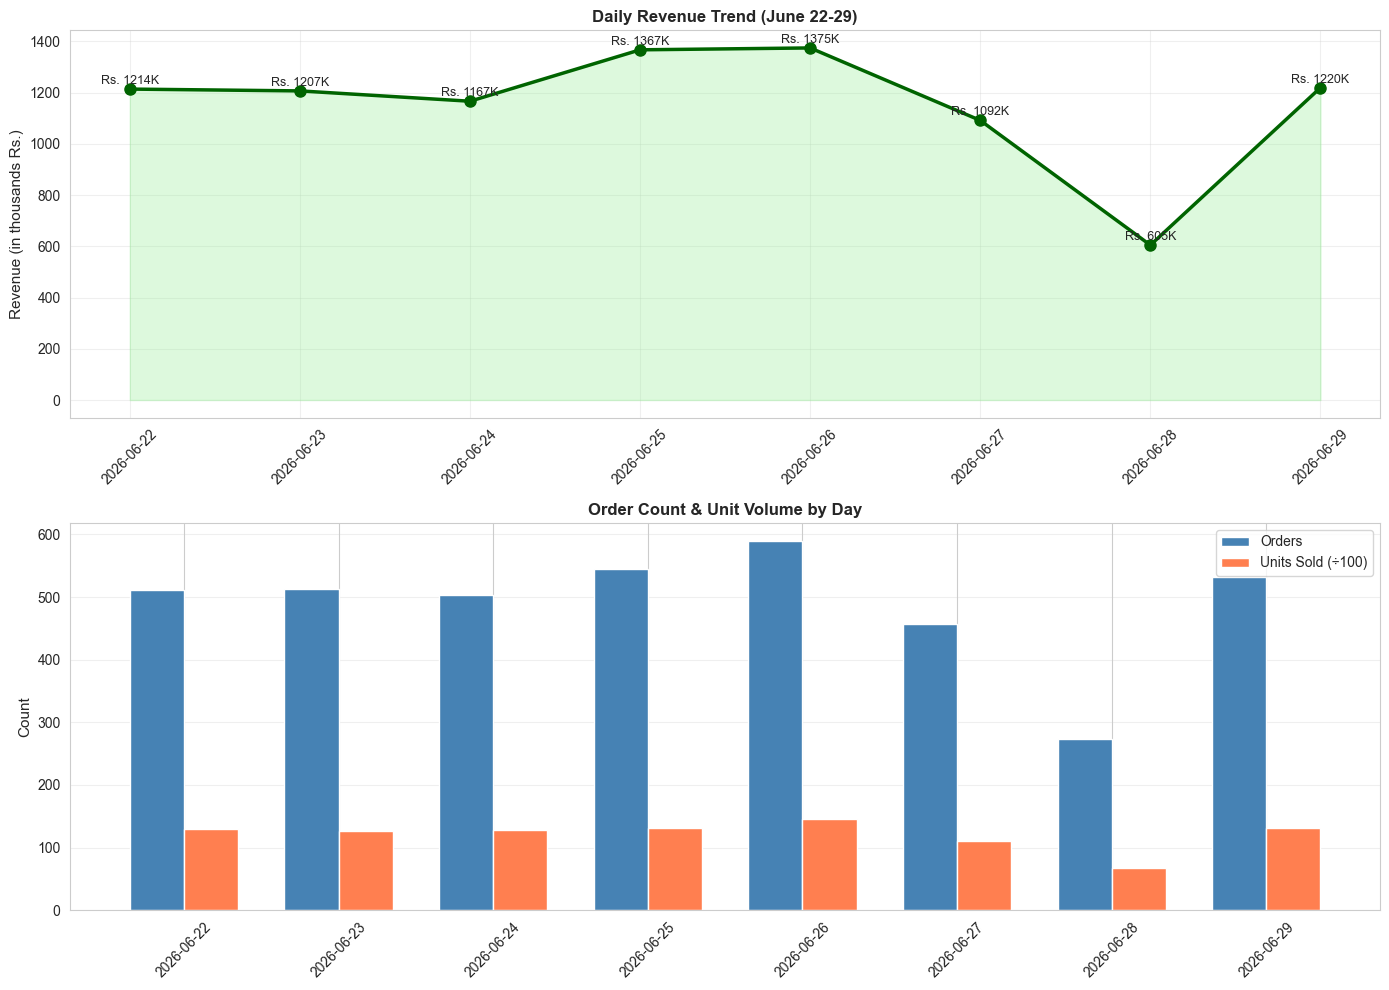


Chart saved as 'daily_trend.png'


In [11]:
# Visualization: Daily revenue trend
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Line chart: Daily revenue
ax1 = axes[0]
x_pos = range(len(daily_trend))
ax1.plot(x_pos, daily_trend['Daily Revenue']/1000, marker='o', linewidth=2.5, markersize=8, color='darkgreen')
ax1.fill_between(x_pos, daily_trend['Daily Revenue']/1000, alpha=0.3, color='lightgreen')
ax1.set_ylabel('Revenue (in thousands Rs.)', fontsize=11)
ax1.set_title('Daily Revenue Trend (June 22-29)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(daily_trend.index, rotation=45)

# Add value labels
for i, v in enumerate(daily_trend['Daily Revenue']):
    ax1.text(i, v/1000 + 20, f'Rs. {v/1000:.0f}K', ha='center', fontsize=9)

# Bar chart: Orders and Units
ax2 = axes[1]
x = range(len(daily_trend))
width = 0.35
ax2.bar([i - width/2 for i in x], daily_trend['Orders'], width, label='Orders', color='steelblue')
ax2.bar([i + width/2 for i in x], daily_trend['Units Sold']/100, width, label='Units Sold (÷100)', color='coral')
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Order Count & Unit Volume by Day', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(daily_trend.index, rotation=45)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('daily_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nChart saved as 'daily_trend.png'")

### Key Observation:
Daily revenue follows a clear **weekly pattern** rather than a simple trend: weekday demand is strongest mid-week, and the weekend (especially Sunday) is the weakest day, since kirana/retail restocking is mainly a weekday activity. With only 8 days of data this is indicative, not conclusive — see `statistical_tests.py` for a formal trend test (the linear trend is not statistically significant).

## 7. Regional Performance

Which regions are performing well and which need support?

In [12]:
regional_analysis = df_sales.groupby('region').agg({
    'order_id': 'count',
    'customer_id': 'nunique',
    'salesperson': 'nunique',
    'revenue': 'sum'
}).round(2)

regional_analysis.columns = ['Orders', 'Unique Customers', 'Salespeople', 'Revenue']
regional_analysis['Avg Order Value'] = (regional_analysis['Revenue'] / regional_analysis['Orders']).round(2)
regional_analysis['Revenue per Salesperson'] = (regional_analysis['Revenue'] / regional_analysis['Salespeople']).round(2)
regional_analysis = regional_analysis.sort_values('Revenue', ascending=False)

print("REGIONAL PERFORMANCE ANALYSIS")
print(regional_analysis.to_string())

REGIONAL PERFORMANCE ANALYSIS
                Orders  Unique Customers  Salespeople     Revenue  Avg Order Value  Revenue per Salesperson
region                                                                                                     
West               968               294           10  2579691.00          2664.97                257969.10
South              988               292           10  2485193.45          2515.38                248519.35
North              753               274           10  1661190.65          2206.10                166119.06
East               650               263           10  1419030.75          2183.12                141903.08
Central            529               244           10  1020264.05          1928.67                102026.40
Unknown Region      37                34           10    80553.75          2177.13                  8055.38


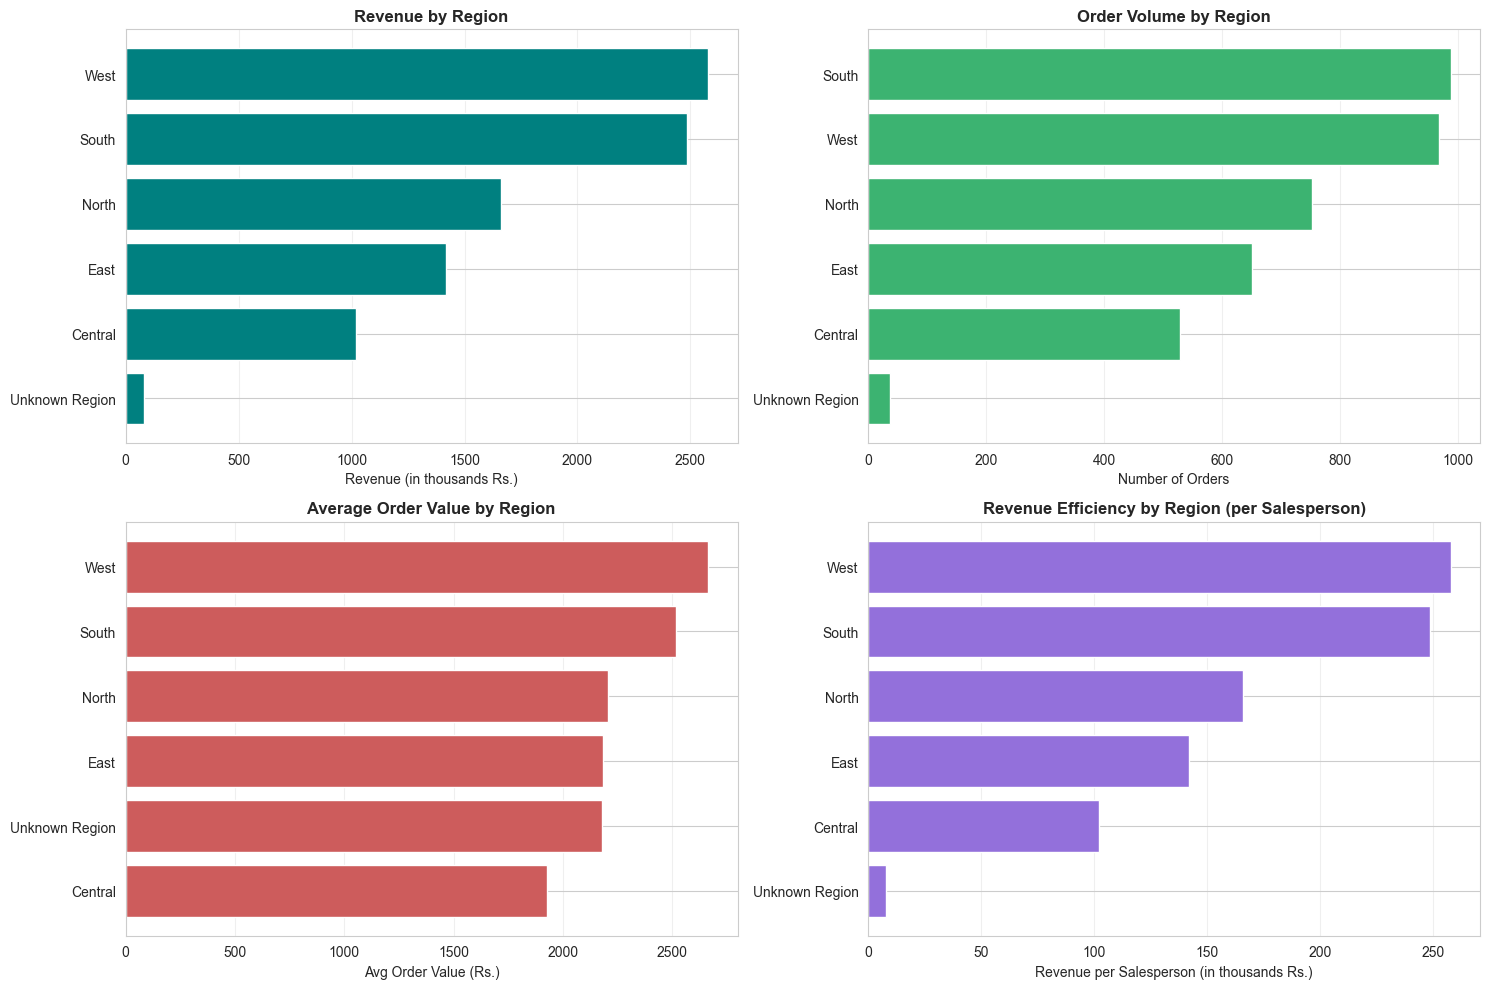


Chart saved as 'regional_analysis.png'


In [13]:
# Visualization: Regional performance
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Revenue by region
ax1 = axes[0, 0]
regional_sorted = regional_analysis.sort_values('Revenue', ascending=True)
ax1.barh(regional_sorted.index, regional_sorted['Revenue']/1000, color='teal')
ax1.set_xlabel('Revenue (in thousands Rs.)')
ax1.set_title('Revenue by Region', fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# 2. Order count by region
ax2 = axes[0, 1]
regional_sorted_orders = regional_analysis.sort_values('Orders', ascending=True)
ax2.barh(regional_sorted_orders.index, regional_sorted_orders['Orders'], color='mediumseagreen')
ax2.set_xlabel('Number of Orders')
ax2.set_title('Order Volume by Region', fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# 3. Avg order value by region
ax3 = axes[1, 0]
regional_sorted_aov = regional_analysis.sort_values('Avg Order Value', ascending=True)
ax3.barh(regional_sorted_aov.index, regional_sorted_aov['Avg Order Value'], color='indianred')
ax3.set_xlabel('Avg Order Value (Rs.)')
ax3.set_title('Average Order Value by Region', fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

# 4. Revenue per salesperson by region
ax4 = axes[1, 1]
regional_sorted_rps = regional_analysis.sort_values('Revenue per Salesperson', ascending=True)
ax4.barh(regional_sorted_rps.index, regional_sorted_rps['Revenue per Salesperson']/1000, color='mediumpurple')
ax4.set_xlabel('Revenue per Salesperson (in thousands Rs.)')
ax4.set_title('Revenue Efficiency by Region (per Salesperson)', fontweight='bold')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('regional_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nChart saved as 'regional_analysis.png'")

## 8. Top Products

Which products are the revenue champions?

In [14]:
product_analysis = df_sales.groupby(['product_name', 'sku_id', 'category']).agg({
    'order_id': 'count',
    'quantity': 'sum',
    'revenue': 'sum'
}).round(2)

product_analysis.columns = ['Orders', 'Units Sold', 'Revenue']
product_analysis['Avg Order Value'] = (product_analysis['Revenue'] / product_analysis['Orders']).round(2)
product_analysis = product_analysis.sort_values('Revenue', ascending=False)

print("TOP 10 PRODUCTS BY REVENUE")
print(product_analysis.head(10).to_string())

TOP 10 PRODUCTS BY REVENUE
                                              Orders  Units Sold    Revenue  Avg Order Value
product_name           sku_id  category                                                     
Amul Butter 500g       DAI-002 Dairy             154        3488  860951.00          5590.59
Amul Ice Cream 750ml   DAI-006 Dairy             159        3844  716849.25          4508.49
Nescafe Classic 50g    BEV-005 Beverages         138        3439  684715.50          4961.71
Glucon-D 500g          BEV-006 Beverages         168        4268  668365.50          3978.37
Haldirams Bhujia 400g  SNK-005 Snacks            124        5228  647406.50          5221.02
Red Bull 250ml         BEV-003 Beverages         162        4195  498981.25          3080.13
Head & Shoulders 340ml PC-002  Personal Care     130        1641  455923.50          3507.10
Britannia Cheese Slice DAI-005 Dairy             175        4174  454945.75          2599.69
Gillette Mach3 Razor   PC-006  Personal Car

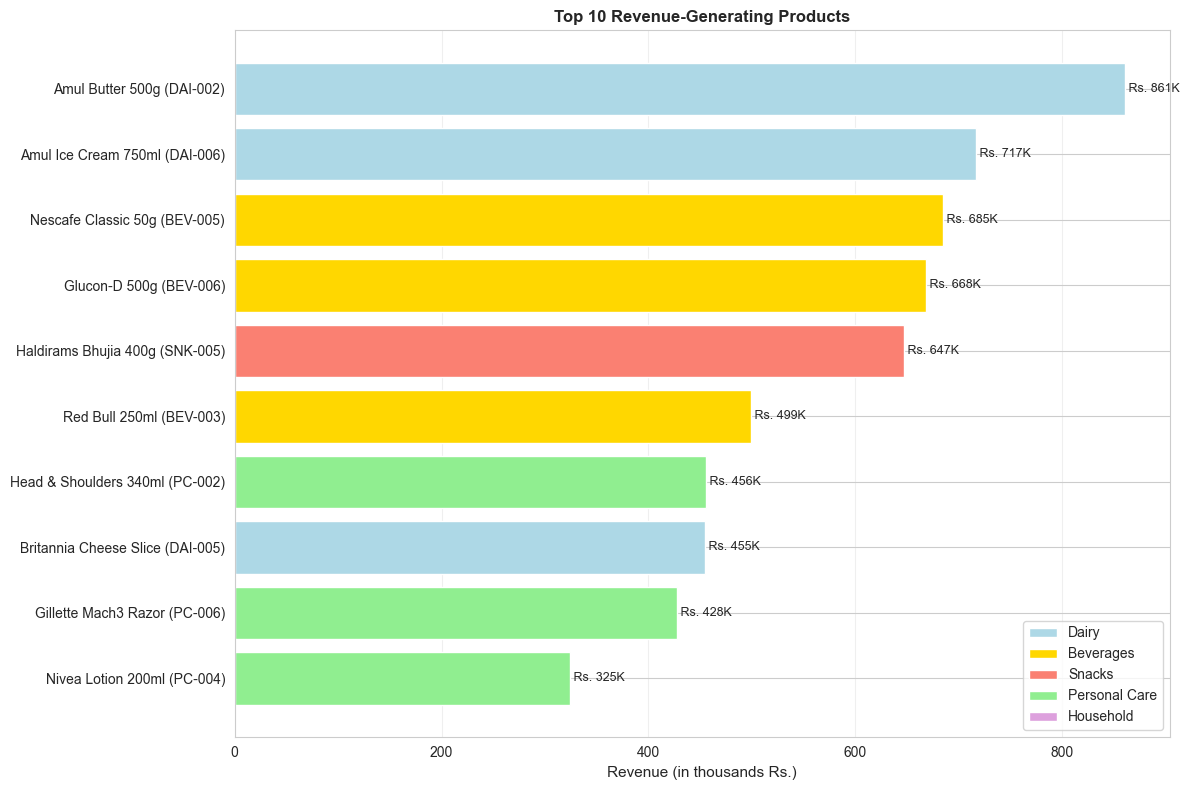


Chart saved as 'top_products.png'


In [15]:
# Visualization: Top 10 products
top10 = product_analysis.head(10).sort_values('Revenue')

fig, ax = plt.subplots(figsize=(12, 8))
colors_map = {'Dairy': 'lightblue', 'Beverages': 'gold', 'Snacks': 'salmon', 
              'Personal Care': 'lightgreen', 'Household': 'plum'}
colors = [colors_map[cat] for cat in top10.index.get_level_values(2)]

bars = ax.barh(range(len(top10)), top10['Revenue']/1000, color=colors)
ax.set_yticks(range(len(top10)))
ax.set_yticklabels([f"{name} ({sku})" for name, sku, _ in top10.index])
ax.set_xlabel('Revenue (in thousands Rs.)', fontsize=11)
ax.set_title('Top 10 Revenue-Generating Products', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top10['Revenue']/1000):
    ax.text(v, i, f' Rs. {v:.0f}K', va='center', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_map[cat], label=cat) for cat in colors_map.keys()]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('top_products.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nChart saved as 'top_products.png'")

## 9. Discount Analysis

Do discounts actually grow revenue, or just give money away? We compare order volume **and net revenue per order** across discount tiers, then test the difference formally in `statistical_tests.py`.

In [16]:
discount_analysis = df_sales.groupby('discount_pct').agg({
    'order_id': 'count',
    'quantity': 'sum',
    'revenue': 'sum',
    'unit_price': lambda x: (x * df_sales.loc[x.index, 'quantity']).sum()  # gross revenue before discount
}).round(2)

discount_analysis.columns = ['Orders', 'Units Sold', 'Net Revenue', 'Gross Revenue']
discount_analysis['Discount Lost'] = discount_analysis['Gross Revenue'] - discount_analysis['Net Revenue']
discount_analysis['Avg Order Value'] = (discount_analysis['Net Revenue'] / discount_analysis['Orders']).round(2)
discount_analysis = discount_analysis.sort_index()

print("DISCOUNT IMPACT ANALYSIS")
print(discount_analysis.to_string())

DISCOUNT IMPACT ANALYSIS
              Orders  Units Sold  Net Revenue  Gross Revenue  Discount Lost  Avg Order Value
discount_pct                                                                                
0               1961       45937   4643140.00        4643140           0.00          2367.74
5                988       24068   2292596.05        2413259      120662.95          2320.44
10               493       13314   1193350.50        1325945      132594.50          2420.59
15               483       13386   1116837.10        1313926      197088.90          2312.29


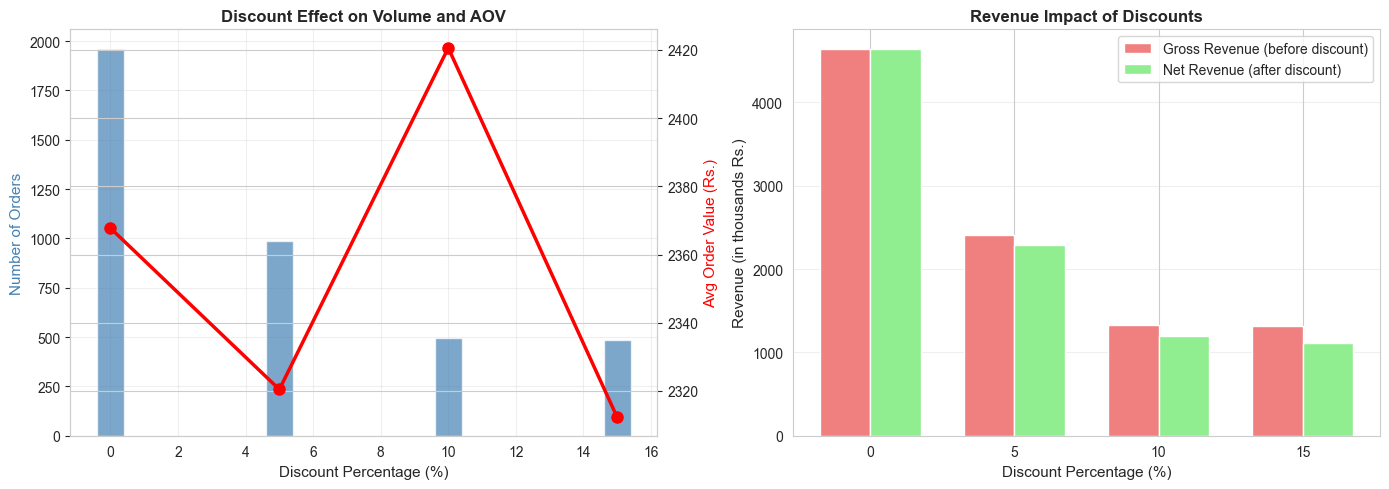


Chart saved as 'discount_analysis.png'


In [17]:
# Visualization: Discount impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Orders and revenue by discount
ax1 = axes[0]
ax1_twin = ax1.twinx()
ax1.bar(discount_analysis.index, discount_analysis['Orders'], alpha=0.7, color='steelblue', label='Order Count')
ax1_twin.plot(discount_analysis.index, discount_analysis['Avg Order Value'], 'ro-', linewidth=2.5, markersize=8, label='Avg Order Value')
ax1.set_xlabel('Discount Percentage (%)', fontsize=11)
ax1.set_ylabel('Number of Orders', fontsize=11, color='steelblue')
ax1_twin.set_ylabel('Avg Order Value (Rs.)', fontsize=11, color='red')
ax1.set_title('Discount Effect on Volume and AOV', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Gross vs Net revenue
ax2 = axes[1]
x = range(len(discount_analysis))
width = 0.35
ax2.bar([i - width/2 for i in x], discount_analysis['Gross Revenue']/1000, width, label='Gross Revenue (before discount)', color='lightcoral')
ax2.bar([i + width/2 for i in x], discount_analysis['Net Revenue']/1000, width, label='Net Revenue (after discount)', color='lightgreen')
ax2.set_xlabel('Discount Percentage (%)', fontsize=11)
ax2.set_ylabel('Revenue (in thousands Rs.)', fontsize=11)
ax2.set_title('Revenue Impact of Discounts', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(discount_analysis.index)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('discount_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nChart saved as 'discount_analysis.png'")

## 10. Key Findings & Business Recommendations

Summary of insights and actionable recommendations.

In [18]:
print("\n" + "="*80)
print("EXECUTIVE SUMMARY: KEY FINDINGS & RECOMMENDATIONS")
print("="*80)

total_revenue = df_sales['revenue'].sum()
total_orders = len(df_sales)
avg_order_value = total_revenue / total_orders

print(f"\n1. REVENUE PERFORMANCE")
print(f"   Total Net Revenue (8-day sample): Rs. {total_revenue:,.2f}")
print(f"   Total Orders: {total_orders:,}")
print(f"   Average Order Value: Rs. {avg_order_value:,.2f}")
print(f"   Daily Average: Rs. {total_revenue/8/1000:,.0f}K per day")

print(f"\n2. PRODUCT MIX")
dairy_pct = category_analysis.loc['Dairy', '% of Revenue'] if 'Dairy' in category_analysis.index else 0
beverages_pct = category_analysis.loc['Beverages', '% of Revenue'] if 'Beverages' in category_analysis.index else 0
print(f"   Dairy products drive {dairy_pct:.1f}% of revenue (Rs. {category_analysis.loc['Dairy', 'Revenue']:,.0f})")
print(f"   Beverages are second at {beverages_pct:.1f}% (Rs. {category_analysis.loc['Beverages', 'Revenue']:,.0f})")
print(f"   Recommendation: keep the two lead categories well stocked.")

print(f"\n3. REGIONAL INSIGHTS")
# Exclude the 'Unknown Region' data-quality bucket from the comparison.
real_regions = regional_analysis.drop(index='Unknown Region', errors='ignore')
best_region = real_regions['Revenue'].idxmax()
worst_region = real_regions['Revenue'].idxmin()
best_revenue = real_regions.loc[best_region, 'Revenue']
worst_revenue = real_regions.loc[worst_region, 'Revenue']
gap = best_revenue - worst_revenue
print(f"   {best_region} leads with Rs. {best_revenue:,.0f}")
print(f"   {worst_region} trails with Rs. {worst_revenue:,.0f}")
print(f"   Revenue gap: Rs. {gap:,.0f} ({gap/worst_revenue*100:.0f}% difference)")
print(f"   This regional difference is statistically significant (ANOVA, see statistical_tests.py),")
print(f"   but most of the gap is order VOLUME, not basket size (per-order effect is small).")
print(f"   Recommendation: prioritise rep coverage / footfall in {worst_region}.")

print(f"\n4. SALES TREND")
max_day = daily_trend['Daily Revenue'].idxmax()
min_day = daily_trend['Daily Revenue'].idxmin()
max_revenue = daily_trend.loc[max_day, 'Daily Revenue']
min_revenue = daily_trend.loc[min_day, 'Daily Revenue']
print(f"   Peak day: {max_day} (Rs. {max_revenue:,.0f})")
print(f"   Weakest day: {min_day} (Rs. {min_revenue:,.0f}) - the weekend/Sunday slump")
print(f"   Recommendation: plan dispatch & staffing around the weekly cycle, not day-to-day noise.")

print(f"\n5. DISCOUNT STRATEGY")
no_discount_revenue = discount_analysis.loc[0, 'Net Revenue']
no_discount_pct = no_discount_revenue / total_revenue * 100
total_discount_given = discount_analysis['Discount Lost'].sum()
print(f"   No-discount orders: {no_discount_pct:.1f}% of revenue")
print(f"   Discounted orders: {100-no_discount_pct:.1f}% of revenue")
print(f"   Revenue given away as discounts: Rs. {total_discount_given:,.0f} (8-day sample)")
print(f"   HOWEVER, net revenue per order does NOT differ significantly across discount tiers")
print(f"   (ANOVA p=0.82, see statistical_tests.py): the volume lift roughly offsets the price cut.")
print(f"   Recommendation: discounting is ~revenue-neutral here, so don't assume cutting it saves money.")
print(f"   (True margin impact would need product COGS, which this dataset does not include.)")

print(f"\n6. DATA QUALITY")
print(f"   Issues found in raw data:")
print(f"   - {missing_names} missing customer names")
print(f"   - {missing_region} missing regions")
print(f"   - {negative_qty} negative quantities")
print(f"   - {duplicates} duplicate orders")
print(f"   Recommendation: validate at point-of-sale (the pipeline already auto-cleans these).")

print(f"\n" + "="*80)


EXECUTIVE SUMMARY: KEY FINDINGS & RECOMMENDATIONS

1. REVENUE PERFORMANCE
   Total Net Revenue (8-day sample): Rs. 9,245,923.65
   Total Orders: 3,925
   Average Order Value: Rs. 2,355.65
   Daily Average: Rs. 1,156K per day

2. PRODUCT MIX
   Dairy products drive 27.2% of revenue (Rs. 2,513,763)
   Beverages are second at 25.7% (Rs. 2,379,847)
   Recommendation: keep the two lead categories well stocked.

3. REGIONAL INSIGHTS
   West leads with Rs. 2,579,691
   Central trails with Rs. 1,020,264
   Revenue gap: Rs. 1,559,427 (153% difference)
   This regional difference is statistically significant (ANOVA, see statistical_tests.py),
   but most of the gap is order VOLUME, not basket size (per-order effect is small).
   Recommendation: prioritise rep coverage / footfall in Central.

4. SALES TREND
   Peak day: 2026-06-26 (Rs. 1,374,724)
   Weakest day: 2026-06-28 (Rs. 604,874) - the weekend/Sunday slump
   Recommendation: plan dispatch & staffing around the weekly cycle, not day-to-day

In [19]:
# Save cleaned data for future reference
df_sales.to_csv('fmcg_sales_cleaned.csv', index=False)
print("Cleaned dataset saved as 'fmcg_sales_cleaned.csv'")

Cleaned dataset saved as 'fmcg_sales_cleaned.csv'


---

## Conclusion

This analysis describes a regional FMCG distribution operation. Key, statistically-checked takeaways:
- **Clear product leaders** (Dairy & Beverages) that warrant inventory focus
- **Real regional & salesperson differences** (significant by ANOVA), driven mostly by order *volume* rather than basket size
- **Discounting is roughly revenue-neutral** in this data (no significant change in net revenue per order across tiers) — not a clear margin lever, and true margin cannot be computed without COGS
- **Data-quality issues** that are common in distributed sales systems and are auto-handled by the cleaning pipeline

**Next Steps:**
1. Collect more history (8 days is too short to forecast; ~6–8 weeks enables a seasonal model)
2. Add product cost (COGS) data to enable genuine margin analysis
3. Prioritise rep coverage in the lagging region(s)
4. Keep the automated validation/cleaning in the daily pipeline

*Note: this notebook runs on simulated data that regenerates daily, so exact figures vary between runs, but the underlying patterns are stable by design.*